## A simple nonlinear problem
Let us consider the forward response (after Menke, 2012)
    $$f(m)= \sin(\omega m_1 x_i) + m_1 m_2$$
a nonlinear function in both model parameters $m_1$ and $m_2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

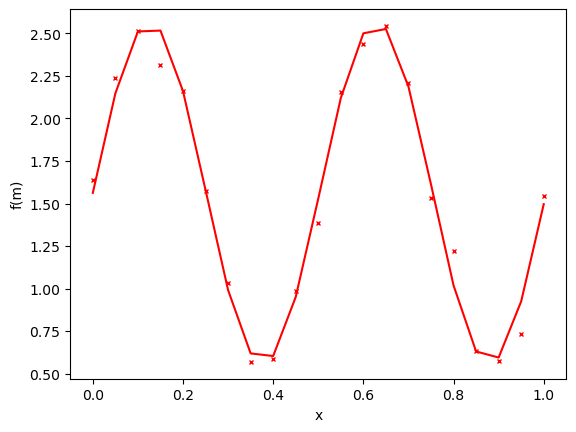

In [2]:
x = np.arange(0, 1.001, 0.05)
omega = 10
forward = lambda m: np.sin(omega * x * m[0]) + m[0] * m[1]
mSynth = [1.25, 1.25]
data = forward(mSynth);
plt.plot(x, data, "r-")
data += np.random.randn(len(data))*0.1;
plt.plot(x, data, "rx");
plt.xlabel("x")
plt.ylabel("f(m)");

### The topology of the objective function
Computation of objective function for a range of model parameters

In [3]:
def showPhi(Phi, mrange, clim=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    if clim is None:
        clim = [np.min(Phi), np.percentile(Phi, 95)]
    ext = [mrange[0], mrange[-1], mrange[-1], mrange[0]]
    im = ax.matshow(Phi.T, extent=ext, vmin=clim[0], vmax=clim[1], cmap="Spectral_r")
    ax.set_xlabel("m1")
    ax.set_ylabel("m2")
    ax.invert_yaxis()
    # fig.colorbar(im);
    return ax

def show2Phi(Phi1, Phi2, mrange, clim=None):
    fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
    if clim is None:
        clim = [np.min(Phi1), np.percentile(Phi1, 95)]
    ext = [mrange[0], mrange[-1], mrange[-1], mrange[0]]
    showPhi(Phi1, mrange, clim=clim, ax=ax[0])
    showPhi(Phi2, mrange, clim=clim, ax=ax[1])
    return ax

def showNPhi(Phis, mrange, clim=None):
    fig, ax = plt.subplots(ncols=len(Phis), sharex=True, sharey=True, figsize=(10, 5))
    if clim is None:
        clim = [np.min(Phis[0]), np.percentile(Phis[0], 95)]
    ext = [mrange[0], mrange[-1], mrange[-1], mrange[0]]
    for i, Phi in enumerate(Phis):
        showPhi(Phi, mrange, clim=clim, ax=ax[i])

    return ax

<Axes: xlabel='m1', ylabel='m2'>

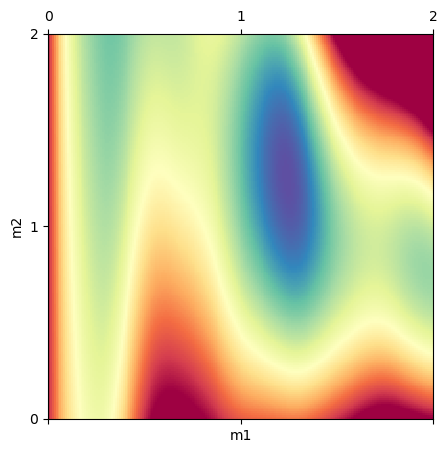

In [4]:
mrange = np.arange(0, 2.001, 0.01)
M1, M2 = np.meshgrid(mrange, mrange)
PhiD = np.zeros([len(mrange), len(mrange)])
for i, m1 in enumerate(mrange):
    for j, m2 in enumerate(mrange):
        PhiD[i, j] = sum((data-forward([m1, m2]))**2) # + 1 * (m1-m2)**2
showPhi(PhiD, mrange)

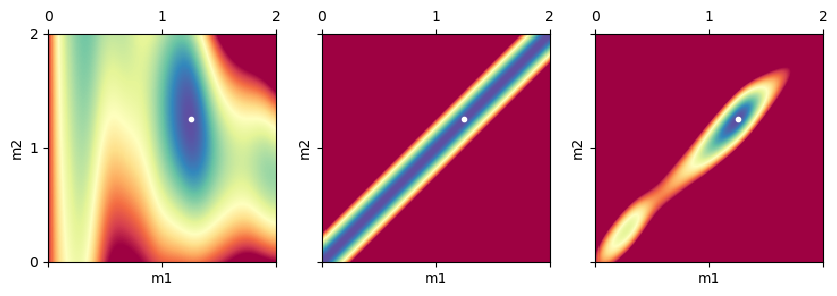

In [5]:
PhiM = (M1-M2)**2
lam = 1000
ax = showNPhi([PhiD, lam*PhiM, PhiD+lam*PhiM], mrange)
for a in ax: a.plot(1.25, 1.25, "wo")
ax[0].figure.savefig(f"phi-lam{lam}.svg")

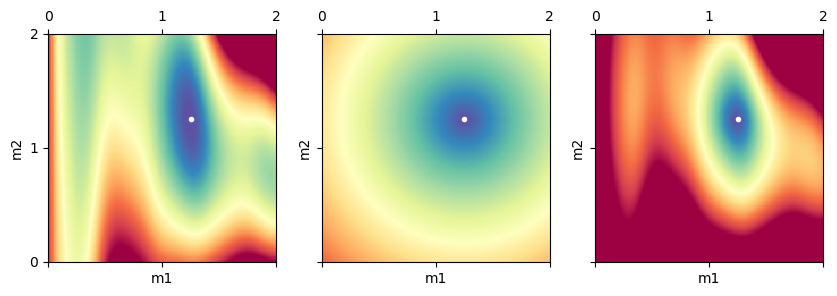

In [6]:
PhiM = np.sqrt((M1-1.25)**2+(M2-1.25)**2)
lam = 30
ax = showNPhi([PhiD, lam*PhiM, PhiD+lam*PhiM], mrange)
for a in ax: a.plot(1.25, 1.25, "wo")
ax[0].figure.savefig(f"phiAp-lam{lam}.svg")

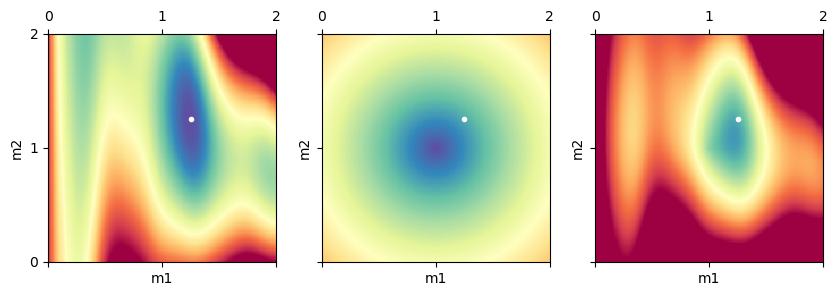

In [7]:
PhiM = np.sqrt((M1-1)**2+(M2-1)**2)
lam = 30
ax = showNPhi([PhiD, lam*PhiM, PhiD+lam*PhiM], mrange)
for a in ax: a.plot(1.25, 1.25, "wo")
ax[0].figure.savefig(f"phiApWrong-lam{lam}.svg")